In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report, f1_score
import timm  # ViT 모델을 불러오기 위한 라이브러리
import copy
import os

# [1] 장치 설정 (3070 Ti 확인)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ 사용 중인 장치: {device}")

# [2] 데이터 전처리
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 데이터 경로 설정
data_dir = r'C:\Users\한민규\Desktop\머신러닝 실습\02_ViT_vs_ResNet\data\Flowers30'
full_dataset = datasets.ImageFolder(data_dir, transform=data_transforms)

# [3] 데이터 3분할 (Train 70%, Val 15%, Test 15%)
full_size = len(full_dataset)
train_size = int(0.7 * full_size)
val_size = int(0.15 * full_size)
test_size = full_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42) # 통계적 재현성
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"📊 데이터 분할 완료: Train({train_size}), Val({val_size}), Test({test_size})")

# [4] ViT 모델 설정
model = timm.create_model('vit_tiny_patch16_224', pretrained=True)
model.head = nn.Linear(model.head.in_features, 30) # 클래스 30개로 수정
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4) # ViT는 Adam 계열을 선호합니다.

# [5] 학습 및 검증 함수
def train_model(num_epochs=10):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_f1 = 0.0
    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        
        for phase in ['train', 'val']:
            if phase == 'train': model.train()
            else: model.eval()

            running_loss = 0.0
            all_labels, all_preds = [], []

            for inputs, labels in (train_loader if phase == 'train' else val_loader):
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())

            epoch_loss = running_loss / (len(train_dataset) if phase == 'train' else len(val_dataset))
            epoch_f1 = f1_score(all_labels, all_preds, average='weighted')
            
            if phase == 'train': train_losses.append(epoch_loss)
            else: val_losses.append(epoch_loss)

            print(f'{phase} Loss: {epoch_loss:.4f} F1-Score: {epoch_f1:.4f}')

            # 가장 좋은 모델 저장 (Validation 기준)
            if phase == 'val' and epoch_f1 > best_f1:
                best_f1 = epoch_f1
                best_model_wts = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_wts)
    return train_losses, val_losses

# [6] 실행 및 저장
train_losses, val_losses = train_model(num_epochs=10)
torch.save(model.state_dict(), 'flower30_vit_tiny.pth')
print("✅ ViT 모델 학습 완료 및 저장!")

# [7] 최종 테스트 (Test Set 평가)
print("\n🔥 최종 Test Set 평가 시작...")
model.eval()
test_labels, test_preds = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        test_labels.extend(labels.cpu().numpy())
        test_preds.extend(preds.cpu().numpy())

print("\n--- 최종 결과 보고서 (Test Set) ---")
print(classification_report(test_labels, test_preds, target_names=full_dataset.classes))

✅ 사용 중인 장치: cuda
📊 데이터 분할 완료: Train(7548), Val(1617), Test(1619)


Epoch 0/9
train Loss: 1.9312 F1-Score: 0.4552
val Loss: 1.0274 F1-Score: 0.7245
Epoch 1/9
train Loss: 0.6502 F1-Score: 0.8181
val Loss: 0.6451 F1-Score: 0.8261
Epoch 2/9
train Loss: 0.1829 F1-Score: 0.9495
val Loss: 0.5616 F1-Score: 0.8649
Epoch 3/9
train Loss: 0.0440 F1-Score: 0.9913
val Loss: 0.4538 F1-Score: 0.8904
Epoch 4/9
train Loss: 0.0070 F1-Score: 0.9996
val Loss: 0.4360 F1-Score: 0.9064
Epoch 5/9
train Loss: 0.0025 F1-Score: 1.0000
val Loss: 0.4306 F1-Score: 0.9054
Epoch 6/9
train Loss: 0.0012 F1-Score: 1.0000
val Loss: 0.4313 F1-Score: 0.9072
Epoch 7/9
train Loss: 0.0009 F1-Score: 1.0000
val Loss: 0.4333 F1-Score: 0.9084
Epoch 8/9
train Loss: 0.0007 F1-Score: 1.0000
val Loss: 0.4375 F1-Score: 0.9065
Epoch 9/9
train Loss: 0.0006 F1-Score: 1.0000
val Loss: 0.4398 F1-Score: 0.9065
✅ ViT 모델 학습 완료 및 저장!

🔥 최종 Test Set 평가 시작...

--- 최종 결과 보고서 (Test Set) ---
               precision    recall  f1-score   support

       Acacia       0.93      0.87      0.90        47
 AfricanDaisy 

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report, f1_score
import copy

# [1] 장치 설정 (3070 Ti)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ 사용 중인 장치: {device}")

# [2] 데이터 전처리 (ViT와 동일하게 224x224 적용)
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 데이터 경로
data_dir = r'C:\Users\한민규\Desktop\머신러닝 실습\02_ViT_vs_ResNet\data\Flowers30'
full_dataset = datasets.ImageFolder(data_dir, transform=data_transforms)

# [3] 데이터 3분할 (ViT와 동일한 시드 42 사용 - 통계적 공정성)
full_size = len(full_dataset)
train_size = int(0.7 * full_size)
val_size = int(0.15 * full_size)
test_size = full_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"📊 ResNet 데이터 분할 완료: Train({train_size}), Val({val_size}), Test({test_size})")

# [4] ResNet-50 모델 설정
model = models.resnet50(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 30) # 30종 분류
model = model.to(device)

criterion = nn.CrossEntropyLoss()
# 비교를 위해 ViT와 동일한 Adam 옵티마이저와 학습률 사용
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# [5] 학습 및 검증 함수
def train_model(num_epochs=10):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_f1 = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        
        for phase in ['train', 'val']:
            if phase == 'train': model.train()
            else: model.eval()

            running_loss = 0.0
            all_labels, all_preds = [], []

            for inputs, labels in (train_loader if phase == 'train' else val_loader):
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())

            epoch_loss = running_loss / (len(train_dataset) if phase == 'train' else len(val_dataset))
            epoch_f1 = f1_score(all_labels, all_preds, average='weighted')
            print(f'{phase} Loss: {epoch_loss:.4f} F1-Score: {epoch_f1:.4f}')

            if phase == 'val' and epoch_f1 > best_f1:
                best_f1 = epoch_f1
                best_model_wts = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_wts)
    return model

# [6] 실행 및 저장
model = train_model(num_epochs=10)
torch.save(model.state_dict(), 'flower30_resnet50_v2.pth')
print("✅ ResNet 모델 학습 완료 및 저장!")

# [7] 최종 테스트 (Test Set 평가)
print("\n🔥 ResNet 최종 Test Set 평가 시작...")
model.eval()
test_labels, test_preds = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        test_labels.extend(labels.cpu().numpy())
        test_preds.extend(preds.cpu().numpy())

print("\n--- ResNet 최종 결과 보고서 (Test Set) ---")
print(classification_report(test_labels, test_preds, target_names=full_dataset.classes))

✅ 사용 중인 장치: cuda
📊 ResNet 데이터 분할 완료: Train(7548), Val(1617), Test(1619)
Epoch 0/9
train Loss: 1.2719 F1-Score: 0.6703
val Loss: 0.6252 F1-Score: 0.8320
Epoch 1/9
train Loss: 0.4038 F1-Score: 0.8947
val Loss: 0.4653 F1-Score: 0.8785
Epoch 2/9
train Loss: 0.1694 F1-Score: 0.9588
val Loss: 0.3972 F1-Score: 0.8941
Epoch 3/9
train Loss: 0.1136 F1-Score: 0.9698
val Loss: 0.4113 F1-Score: 0.8947
Epoch 4/9
train Loss: 0.0533 F1-Score: 0.9891
val Loss: 0.4088 F1-Score: 0.8993
Epoch 5/9
train Loss: 0.0728 F1-Score: 0.9799
val Loss: 0.4609 F1-Score: 0.8917
Epoch 6/9
train Loss: 0.0823 F1-Score: 0.9784
val Loss: 0.4974 F1-Score: 0.8848
Epoch 7/9
train Loss: 0.1021 F1-Score: 0.9695
val Loss: 0.5064 F1-Score: 0.8743
Epoch 8/9
train Loss: 0.0856 F1-Score: 0.9757
val Loss: 0.4876 F1-Score: 0.8929
Epoch 9/9
train Loss: 0.0466 F1-Score: 0.9867
val Loss: 0.4258 F1-Score: 0.9060
✅ ResNet 모델 학습 완료 및 저장!

🔥 ResNet 최종 Test Set 평가 시작...

--- ResNet 최종 결과 보고서 (Test Set) ---
               precision    recall  

C:\Users\한민규\AppData\Local\Temp\ipykernel_4912\3745285312.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  resnet.load_state_dict(torch.load(resnet_path))
C:\Users\한민규\A

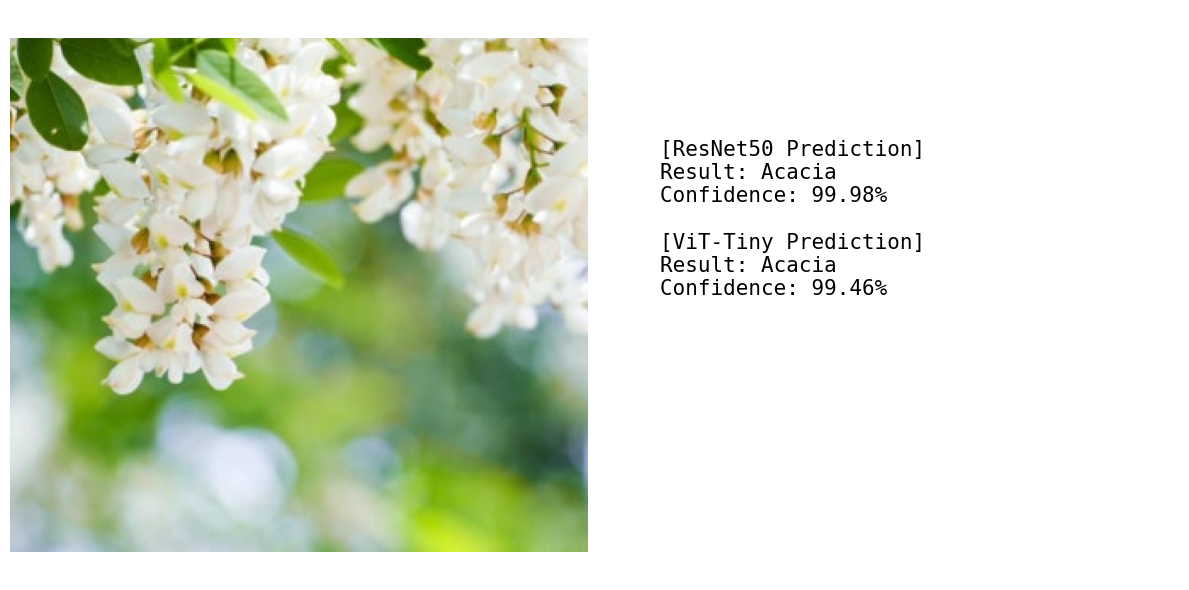

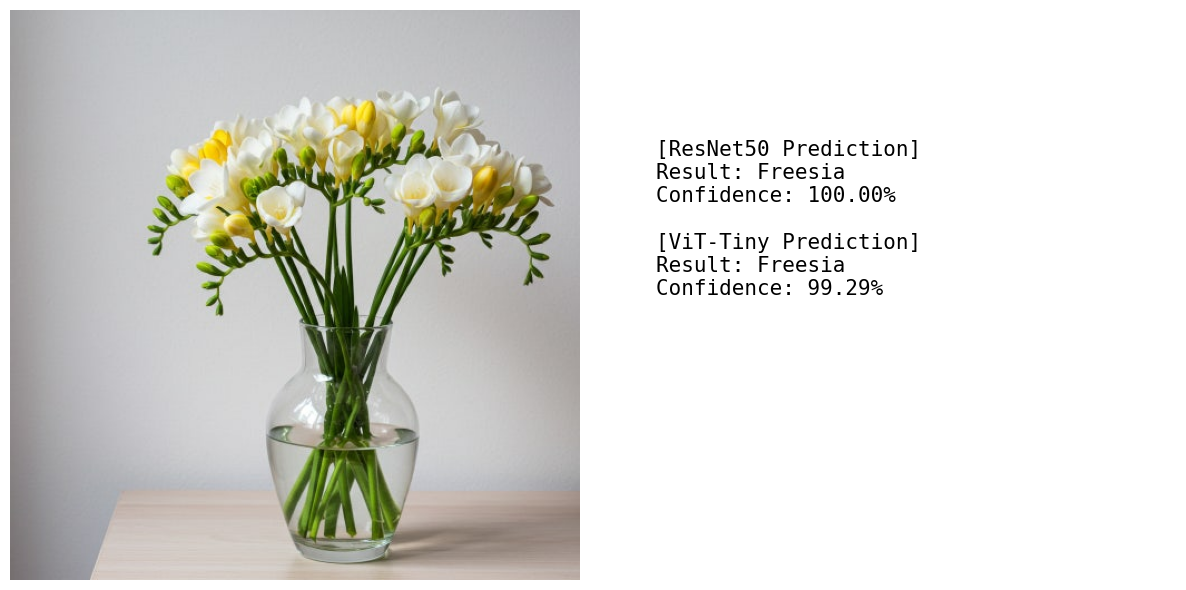

In [8]:
import torch
import torch.nn as nn
from torchvision import transforms, models
import timm
from PIL import Image
import matplotlib.pyplot as plt

# [1] 장치 설정 (3070 Ti 가속)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# [2] 모델 로드 함수 (저장된 .pth 파일을 불러옵니다)
def load_trained_models(resnet_path, vit_path, num_classes=30):
    # 1. ResNet50 설정 및 불러오기
    resnet = models.resnet50()
    resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)
    resnet.load_state_dict(torch.load(resnet_path))
    resnet = resnet.to(device).eval()

    # 2. ViT-Tiny 설정 및 불러오기
    vit = timm.create_model('vit_tiny_patch16_224', pretrained=False)
    vit.head = nn.Linear(vit.head.in_features, num_classes)
    vit.load_state_dict(torch.load(vit_path))
    vit = vit.to(device).eval()
    
    return resnet, vit

# [3] 이미지 전처리 설정 (학습 때와 동일한 정규화 값 사용)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# [4] 두 모델 통합 예측 함수
def predict_battle(image_path, resnet, vit, class_names):
    # 이미지 불러오기 및 변환
    img = Image.open(image_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        # ResNet50 추론
        res_out = resnet(img_tensor)
        res_prob = torch.nn.functional.softmax(res_out, dim=1)
        res_conf, res_pred = torch.max(res_prob, 1)

        # ViT-Tiny 추론
        vit_out = vit(img_tensor)
        vit_prob = torch.nn.functional.softmax(vit_out, dim=1)
        vit_conf, vit_pred = torch.max(vit_prob, 1)

    # 시각화 (두 결과를 한 번에 보여줌)
    plt.figure(figsize=(12, 6))
    
    # 원본 이미지 출력
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.axis('off')

    # 텍스트 결과 요약
    result_text = (
        f"[ResNet50 Prediction]\n"
        f"Result: {class_names[res_pred[0]]}\n"
        f"Confidence: {res_conf[0]*100:.2f}%\n\n"
        f"[ViT-Tiny Prediction]\n"
        f"Result: {class_names[vit_pred[0]]}\n"
        f"Confidence: {vit_conf[0]*100:.2f}%"
    )
    
    plt.subplot(1, 2, 2)
    plt.text(0.1, 0.5, result_text, fontsize=15, family='monospace')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# [5] 실제 실행 부분
class_names = full_dataset.classes 

# 모델 파일 경로 (파일이 있는 경로로 수정하세요)
RESNET_PATH = 'flower30_resnet50_v2.pth'
VIT_PATH = 'flower30_vit_tiny.pth'

# 모델 불러오기
resnet_model, vit_model = load_trained_models(RESNET_PATH, VIT_PATH)

# 테스트하고 싶은 이미지 경로를 넣으세요!
predict_battle(r'C:\Users\한민규\Desktop\머신러닝 실습\02_ViT_vs_ResNet\data\아카시아.jpg', resnet_model, vit_model, class_names)

predict_battle(r'C:\Users\한민규\Desktop\머신러닝 실습\02_ViT_vs_ResNet\data\프리지아.jpg', resnet_model, vit_model, class_names)